## Bài 1: Linear Regression với dữ liệu rải quanh một đường thẳng

Bộ dữ liệu bên dưới mô phỏng các điểm `x` nằm rải rác quanh đường thẳng thật gần đúng `y = 2.4x - 1.2`.

Yêu cầu học sinh:
- Tính dự đoán `y_pred`.
- Tính MSE loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.
- In loss để quan sát quá trình học.

In [11]:
import numpy as np

# Dữ liệu linear regression
x_linear = np.array([-3.0, -2.4, -1.8, -1.2, -0.6, 0.0, 0.6, 1.2, 1.8, 2.4, 3.0])
y_linear = np.array([-8.7, -6.6, -5.4, -4.0, -2.4, -1.0, 0.0, 1.6, 3.0, 4.7, 6.2])

# Tham số khởi tạo đã cho
w_linear = 0.3
b_linear = 0.0
learning_rate_linear = 0.03
epochs_linear = 120

print("x_linear =", x_linear)
print("y_linear =", y_linear)
print("w_linear ban đầu =", w_linear)
print("b_linear ban đầu =", b_linear)
print("learning_rate_linear =", learning_rate_linear)

x_linear = [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]
y_linear = [-8.7 -6.6 -5.4 -4.  -2.4 -1.   0.   1.6  3.   4.7  6.2]
w_linear ban đầu = 0.3
b_linear ban đầu = 0.0
learning_rate_linear = 0.03


### Bài 1.1: Hoàn thiện hàm cho Linear Regression


In [12]:
# TODO: viết hàm predict_linear(x, w, b)
def predict_linear(x, w, b):
    return w*x + b
# TODO: viết hàm mse_loss(y_true, y_pred)
def mse_loss(y_true, y_pred):
    error = y_pred - y_true
    return np.mean(error ** 2)
# TODO: viết hàm compute_linear_gradients(x, y_true, y_pred)
def compute_linear_gradients (x, y_true, y_pred):
    error = y_pred - y_true
    grad_w = 2 * np.mean(error * x)
    grad_b = 2 * np.mean(error)
    return grad_w, grad_b

### Bài 1.2: Huấn luyện mô hình Linear Regression

Sau khi chạy xong, `w_linear` và `b_linear` nên tiến gần tới đường thẳng phù hợp với dữ liệu.

In [13]:
loss_history_linear = []

for epoch in range(epochs_linear):
    # tính giá trị dự đoán
    y_pred_linear = predict_linear(x_linear, w_linear, b_linear)

    # Tính loss
    loss_linear = mse_loss(y_linear, y_pred_linear)
    loss_history_linear.append(loss_linear)

    # tính gradient
    grad_w_linear, grad_b_linear = compute_linear_gradients(x_linear, y_linear, y_pred_linear)

    # update
    w_linear = w_linear - learning_rate_linear * grad_w_linear
    b_linear = b_linear - learning_rate_linear * grad_b_linear
    
    if epoch % 20 == 0 or epoch == epochs_linear - 1:
        print(f"epoch {epoch:3d} | loss = {loss_linear:8.4f} | w = {w_linear:6.3f} | b = {b_linear:6.3f}")

epoch   0 | loss =  17.2513 | w =  0.754 | b = -0.069
epoch  20 | loss =   0.1517 | w =  2.389 | b = -0.833
epoch  40 | loss =   0.0496 | w =  2.401 | b = -1.055
epoch  60 | loss =   0.0411 | w =  2.402 | b = -1.119
epoch  80 | loss =   0.0404 | w =  2.402 | b = -1.138
epoch 100 | loss =   0.0403 | w =  2.402 | b = -1.143
epoch 119 | loss =   0.0403 | w =  2.402 | b = -1.145


### Bài 1.3: Viết hàm plot kết quả Linear Regression

Viết hàm trực quan hóa để kiểm tra đường thẳng mô hình học được có khớp với dữ liệu hay không.

AttributeError: Line2D.set() got an unexpected keyword argument 'xlabel'

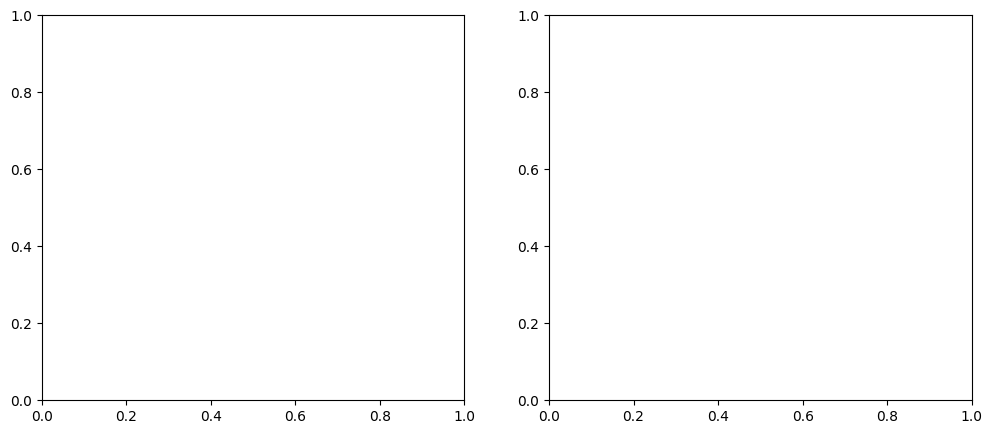

In [ ]:
import matplotlib.pyplot as plt

# TODO: viết hàm plot_linear_result(x, y_true, w, b, loss_history)
def plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear):
    epochs_axis = np.arange(len(loss_history_linear))
    y_pred_linear = predict_linear(x_linear, w_linear, b_linear)

    fig, (ax1, ax2) = plt.subplots( nrows = 1,
                                    ncols =  2, 
                                    figsize=(12, 5))

    ax1.plot(epochs_axis,
             loss_history_linear,
             color = "tab:blue",
             linewidth = 2,
             xlabel = "Epoch",
             ylabel = "Loss MSE",
             title = "Loss theo epoch",
             grid = True, alpha = 0.3)
    
    ax2.scatter(x_linear, 
                y_linear, 
                color = "tab:orange", 
                label = "Dữ liệu thật")
    ax2.plot(x_linear,
             y_linear,
             color = "tab:blue",
             linewidth = 2,
             xlabel = "x",
             ylabel = "y",
             title = f"Đường thẳng học được: y = {w_linear:.2f}x + {b_linear:.2f}",
             grid = True, alpha = 0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()

def plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear):
    epochs_axis = np.arange(len(loss_history_linear))
    y_pred_linear = predict_linear(x_linear, w_linear, b_linear)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    ax1.plot(epochs_axis, loss_history_linear, color="tab:blue", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss MSE")
    ax1.set_title("Loss theo epoch")
    ax1.grid(True, alpha=0.3)
    
    ax2.scatter(x_linear, y_linear, color="tab:orange", label="Dữ liệu thật")
    ax2.plot(x_linear, y_pred_linear, color="tab:blue", linewidth=2)
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_title(f"Đường thẳng học được: y = {w_linear:.2f}x + {b_linear:.2f}")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear)
# Gợi ý: tạo biểu đồ gồm 2 phần
# - Phần 1: vẽ loss_history theo epoch
# - Phần 2: scatter dữ liệu thật và vẽ đường y_pred = w * x + b
# - Thêm title, xlabel, ylabel, legend để biểu đồ dễ đọc

# TODO: gọi plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear)